#Trabalho de Redes

Este é o trabalho final da matéria Redes de Computadores I.

#Célula 1: Configurações, Imports e Sessões Robustas
Nesta célula, além de importar as bibliotecas, configuramos uma sessão HTTP resiliente. Se a API do RIPEstat der um erro temporário (como Timeout ou Too Many Requests), o script vai esperar e tentar de novo automaticamente, em vez de simplesmente travar.

In [3]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm
import time

# Definindo os ASNs alvo ampliados (Rivalidade EUA-China)
TARGET_ASNS = {
    # Gigantes da China (Foco em Conteúdo e Nuvem)
    "136907": {"nome": "Huawei Cloud", "pais": "CN"},
    "45102":  {"nome": "Alibaba Cloud", "pais": "CN"},
    "132203": {"nome": "Tencent", "pais": "CN"},
    "55990":  {"nome": "JD.com", "pais": "CN"},
    "38365":  {"nome": "Baidu", "pais": "CN"},

    # Gigantes dos EUA (Foco em Conteúdo e Nuvem)
    "8075":   {"nome": "Microsoft", "pais": "US"},
    "15169":  {"nome": "Google", "pais": "US"},
    "32934":  {"nome": "Meta (Facebook)", "pais": "US"},
    "2906":   {"nome": "Netflix", "pais": "US"},
    "13414":  {"nome": "X (Twitter)", "pais": "US"}
}

# Configurando uma sessão HTTP robusta com retry
session = requests.Session()
retry_strategy = Retry(
    total=3, # Tenta até 3 vezes antes de falhar
    backoff_factor=1, # Espera 1s, 2s, 4s entre tentativas
    status_forcelist=[429, 500, 502, 503, 504] # Códigos de erro da API que disparam o retry
)
adapter = HTTPAdapter(max_retries=retry_strategy)
session.mount("http://", adapter)
session.mount("https://", adapter)

# Cache de países para não sobrecarregar a API
asn_country_cache = {}

#Célula 2: Funções de Coleta com Cache e Tratamento
Aqui temos as duas funções que conversam com a internet. A primeira pega os caminhos, a segunda descobre o país de um AS. Note que a get_as_country agora usa o nosso dicionário asn_country_cache. Isso reduz o tempo de execução de minutos para poucos segundos.

In [4]:
import time
import requests

session = requests.Session()
asn_country_cache = {}

def get_bgp_paths(asn):
    """Busca todos os AS_PATHs visíveis que chegam ao ASN alvo (via RIPEstat)."""
    url = f"https://stat.ripe.net/data/bgp-state/data.json?resource=AS{asn}"

    # Tenta baixar até 3 vezes antes de desistir (Cobre Timeout e Erros 500/502)
    for tentativa in range(3):
        try:
            response = session.get(url, timeout=120)
            response.raise_for_status() # Dispara exceção se o status for 4xx ou 5xx
            data = response.json()

            paths = [route.get('path', []) for route in data.get('data', {}).get('bgp_state', []) if route.get('path')]
            return paths

        except (requests.exceptions.ReadTimeout, requests.exceptions.HTTPError) as e:
            print(f"Instabilidade no AS{asn} (Erro de servidor ou Timeout). Tentativa {tentativa + 1} de 3...")
            time.sleep(10) # Pausa de 10 segundos para o RIPEstat se recuperar do 502

        except Exception as e:
            print(f"Erro Crítico não contornável para AS{asn}: {e}")
            return []

    print(f"Falha definitiva ao buscar AS{asn} após 3 tentativas.")
    return []

def get_as_country(asn):
    """
    Descobre o país de um ASN usando o RIPEstat RIR-GEO (Requisito do Trabalho).
    """
    asn_str = str(asn)

    # Checa o cache primeiro para economizar requisições
    if asn_str in asn_country_cache:
        return asn_country_cache[asn_str]

    # Tentativa Principal: Endpoint oficial de Geolocalização do RIPEstat
    try:
        resp = session.get(f"https://stat.ripe.net/data/rir-geo/data.json?resource=AS{asn_str}", timeout=5)
        if resp.status_code == 200:
            resources = resp.json().get('data', {}).get('located_resources', [])
            if resources and len(resources) > 0:
                country = resources[0].get('location')
                if country and len(country) == 2:
                    asn_country_cache[asn_str] = country.upper()
                    return country.upper()
    except:
        pass

    # Tentativa de Segurança: RDAP (Protocolo Oficial de Registro IANA)
    try:
        resp = session.get(f"https://rdap.org/autnum/{asn_str}", timeout=5)
        if resp.status_code == 200:
            country = resp.json().get('country')
            if country and len(country) == 2:
                asn_country_cache[asn_str] = country.upper()
                return country.upper()
    except:
        pass

    # Se falhar em tudo, marca como desconhecido
    asn_country_cache[asn_str] = "UNKNOWN"
    return "UNKNOWN"

#Célula 3: O Motor de Análise e as 3 Métricas
Este é o núcleo analítico do seu trabalho. Ele processa as rotas para extrair o tamanho médio, a concentração no top-5 e a fração de infraestrutura estrangeira.

In [5]:
results = []

print("Iniciando coleta e processamento das rotas BGP...")
for target_asn, info in tqdm(TARGET_ASNS.items(), desc="Processando Alvos"):
    paths = get_bgp_paths(target_asn)
    if not paths:
        continue

    # Tamanho Médio do Caminho
    total_path_length = sum(len(p) for p in paths)
    avg_path_len = total_path_length / len(paths)

    # Concentração Top-5 (Upstreams diretos)
    upstreams = [p[-2] for p in paths if len(p) > 1]
    upstream_counts = Counter(upstreams)
    top5_count = sum(count for asn, count in upstream_counts.most_common(5))
    top5_concentration = (top5_count / len(upstreams)) * 100 if upstreams else 0

    # Fração Estrangeira Otimizada (Amostragem dos Top 100)
    all_transit_ases = []
    for p in paths:
        if len(p) > 2:
            all_transit_ases.extend(p[1:-1])

    # Conta a frequência e pega apenas os 100 provedores mais importantes para aquela rede
    transit_counts = Counter(all_transit_ases)
    top_transit = transit_counts.most_common(100)

    foreign_hits = 0
    total_evaluated_hits = 0

    for asn, frequency in top_transit:
        country = get_as_country(asn)
        if country != "UNKNOWN":
            total_evaluated_hits += frequency
            if country != info["pais"]:
                foreign_hits += frequency
        time.sleep(0.05) # Pausa de 50 milissegundos para não tomar block da API

    # Calcula a fração baseada no volume de rotas (hits)
    foreign_fraction = (foreign_hits / total_evaluated_hits) * 100 if total_evaluated_hits > 0 else 0

    unique_ases = set(asn_item for path in paths for asn_item in path)

    # Salvando os resultados
    results.append({
        'Empresa': info['nome'],
        'ASN': asn,
        'País Sede': info['pais'],
        'Rotas Únicas': len(paths),
        'Tamanho Médio AS_PATH': round(avg_path_len, 2),
        'Concentração Top-5 (%)': round(top5_concentration, 2),
        'Fração de ASes Estrangeiros (%)': round(foreign_fraction, 2),
        'Diversidade de ASes': len(unique_ases)
    })

# Consolidação no Pandas
df_results = pd.DataFrame(results)
display(df_results)
df_results.to_csv("metricas_finais_bgp.csv", index=False)
print("\nDados salvos em 'metricas_finais_bgp.csv'.")

Iniciando coleta e processamento das rotas BGP...


Processando Alvos:   0%|          | 0/10 [00:00<?, ?it/s]

,Empresa,ASN,País Sede,Rotas Únicas,Tamanho Médio AS_PATH,Concentração Top-5 (%),Fração de ASes Estrangeiros (%),Diversidade de ASes
0,Huawei Cloud,50304,CN,211549,3.97,49.55,99.27,523
1,Alibaba Cloud,3462,CN,402948,4.00,66.58,84.86,503
2,Tencent,1853,CN,371319,3.81,56.20,94.12,500
3,JD.com,9009,CN,136852,5.01,84.09,25.86,428
4,Baidu,64126,CN,45000,5.47,98.87,25.30,379
5,Microsoft,4755,US,453075,2.29,12.64,79.94,405
6,Google,56308,US,448095,2.36,15.12,71.57,452
7,Meta (Facebook),8772,US,145731,3.23,66.68,56.91,495
8,Netflix,15935,US,109730,3.23,58.84,46.11,513
9,X (Twitter),9044,US,11367,4.67,100.00,20.13,351



Dados salvos em 'metricas_finais_bgp.csv'.


#Célula 4: A Geração dos Gráficos (DataViz)
O enunciado pede dois ou três gráficos. Aqui estamos gerando três figuras com design limpo (seaborn) e ajustando as legendas.

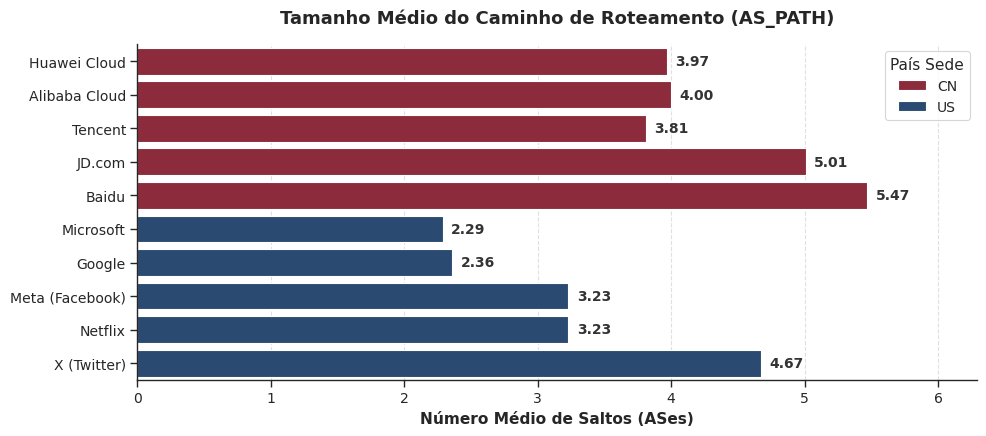

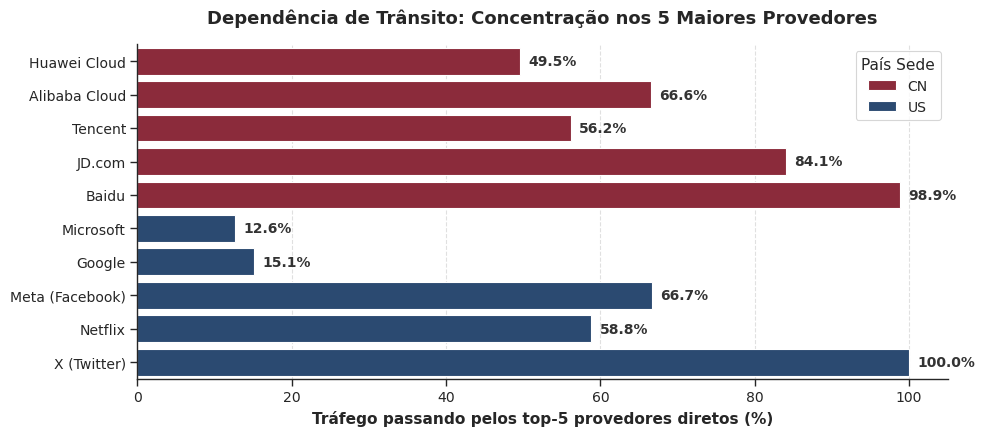

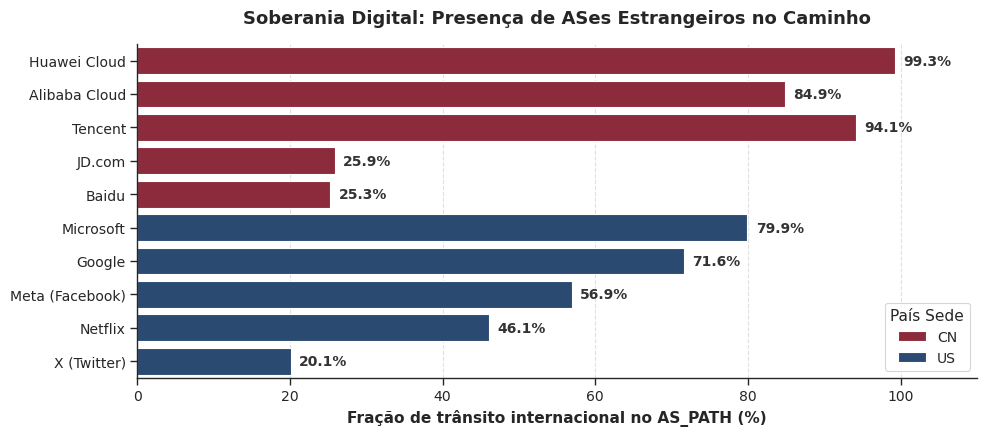

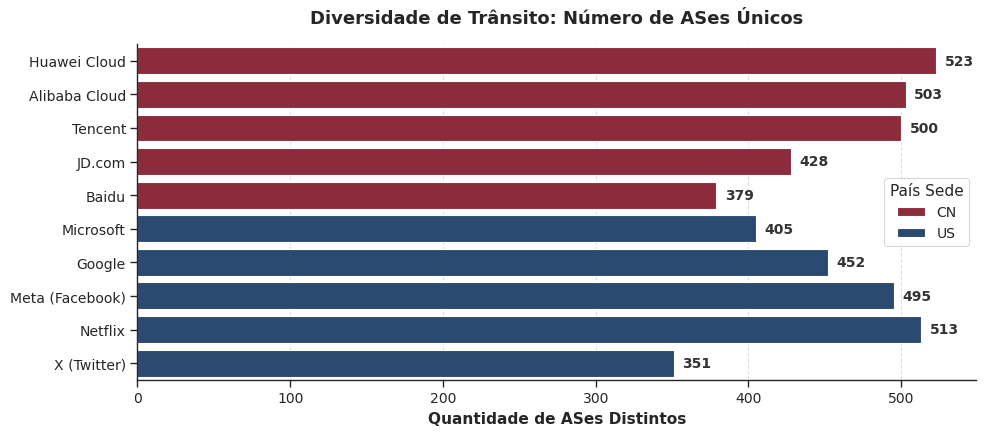

Gráficos gerados com sucesso!


In [8]:
if df_results.empty:
    print("Aviso: A tabela de dados está vazia! Não é possível gerar os gráficos. Verifique a coleta.")
else:
    sns.set_theme(style="ticks", context="paper", font_scale=1.15)
    PALETA = {"CN": "#9B1B30", "US": "#1F497D"}

    def adicionar_rotulos(ax, formato='{:.2f}'):
        for p in ax.patches:
            largura = p.get_width()
            if largura > 0:
                ax.annotate(formato.format(largura),
                            (largura, p.get_y() + p.get_height() / 2.),
                            ha='left', va='center',
                            xytext=(6, 0), textcoords='offset points',
                            fontsize=10, color='#333333', fontweight='bold')

    # Gráfico 1: Tamanho médio AS_PATH
    plt.figure(figsize=(10, 4.5))
    ax1 = sns.barplot(x="Tamanho Médio AS_PATH", y="Empresa", hue="País Sede", data=df_results, palette=PALETA)
    plt.title("Tamanho Médio do Caminho de Roteamento (AS_PATH)", pad=15, fontweight='bold', fontsize=13)
    plt.xlabel("Número Médio de Saltos (ASes)", fontweight='bold')
    plt.ylabel("")
    plt.xlim(0, df_results["Tamanho Médio AS_PATH"].max() * 1.15)

    sns.despine()
    ax1.xaxis.grid(True, linestyle='--', alpha=0.6)
    adicionar_rotulos(ax1)

    plt.tight_layout()
    plt.savefig("metrica1_aspath_pro.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Gráfico 2: Concentração Top-5
    plt.figure(figsize=(10, 4.5))
    ax2 = sns.barplot(x="Concentração Top-5 (%)", y="Empresa", hue="País Sede", data=df_results, palette=PALETA)
    plt.title("Dependência de Trânsito: Concentração nos 5 Maiores Provedores", pad=15, fontweight='bold', fontsize=13)
    plt.xlabel("Tráfego passando pelos top-5 provedores diretos (%)", fontweight='bold')
    plt.ylabel("")
    plt.xlim(0, 105)

    sns.despine()
    ax2.xaxis.grid(True, linestyle='--', alpha=0.6)
    adicionar_rotulos(ax2, formato='{:.1f}%')

    plt.tight_layout()
    plt.savefig("metrica2_dependencia_pro.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Gráfico 3: Fração Estrangeira
    plt.figure(figsize=(10, 4.5))
    ax3 = sns.barplot(x="Fração de ASes Estrangeiros (%)", y="Empresa", hue="País Sede", data=df_results, palette=PALETA)
    plt.title("Soberania Digital: Presença de ASes Estrangeiros no Caminho", pad=15, fontweight='bold', fontsize=13)
    plt.xlabel("Fração de trânsito internacional no AS_PATH (%)", fontweight='bold')
    plt.ylabel("")
    plt.xlim(0, 110)

    sns.despine()
    ax3.xaxis.grid(True, linestyle='--', alpha=0.6)
    adicionar_rotulos(ax3, formato='{:.1f}%')

    plt.tight_layout()
    plt.savefig("metrica3_soberania_pro.png", dpi=300, bbox_inches='tight')
    plt.show()

    # Gráfico 4: Diversidade de Trânsito
    plt.figure(figsize=(10, 4.5))
    ax4 = sns.barplot(x="Diversidade de ASes", y="Empresa", hue="País Sede", data=df_results, palette=PALETA)
    plt.title("Diversidade de Trânsito: Número de ASes Únicos", pad=15, fontweight='bold', fontsize=13)
    plt.xlabel("Quantidade de ASes Distintos", fontweight='bold')
    plt.ylabel("")

    sns.despine()
    ax4.xaxis.grid(True, linestyle='--', alpha=0.6)

    # Como estamos contando a quantidade absoluta de ASes, usamos '{:.0f}' para números inteiros
    adicionar_rotulos(ax4, formato='{:.0f}')

    plt.tight_layout()
    plt.savefig("metrica4_diversidade_pro.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("Gráficos gerados com sucesso!")